# ShowTime OTT Platform - First-Day Content Viewership Analysis

## Project Objective
The objective of this project is to determine the key factors that drive first-day content viewership on ShowTime, an OTT (Over-the-Top) media service provider. With changing customer behavior and growing competition in the streaming industry, it is crucial for ShowTime to understand what influences early viewership patterns. 

Using exploratory data analysis (EDA) and linear regression modeling, this project aims to:
- Analyze platform metrics like visitors, ad impressions, trailer views, genre, seasonality, and day of release
- Identify major patterns, correlations, and trends affecting viewership
- Build and validate a predictive model to determine significant drivers of first-day content performance
- Provide actionable insights for marketing and content release strategies

## Business Context
OTT streaming services have experienced exponential growth in recent years, especially with changing consumer habits and the impact of global events like the COVID-19 pandemic. ShowTime seeks to optimize its content marketing and scheduling by leveraging data-driven insights.

Through this analysis, ShowTime will be better equipped to:
- Improve promotional strategies
- Schedule content releases strategically
- Maximize first-day content consumption

### Import Necessary Libraries

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# split the data into train and test
from sklearn.model_selection import train_test_split

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# to build linear regression_model using statsmodels
import statsmodels.api as sm

# to compute VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

### Load the dataset

In [2]:
df= pd.read_csv('ottdata.csv')

## Data Overview

The initial steps to get an overview of any dataset is to:
- observe the first few rows of the dataset, to check whether the dataset has been loaded properly or not
- get information about the number of rows and columns in the dataset
- find out the data types of the columns to ensure that data is stored in the preferred format and the value of each property is as expected.
- check the statistical summary of the dataset to get an overview of the numerical columns of the data

### Displaying the first few rows of the dataset

In [3]:
df.head()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
0,1.67,1113.81,0,Horror,Wednesday,Spring,56.70,0.51
1,1.46,1498.41,1,Thriller,Friday,Fall,52.69,0.32
2,1.47,1079.19,1,Thriller,Wednesday,Fall,48.74,0.39
3,1.85,1342.77,1,Sci-Fi,Friday,Fall,49.81,0.44
4,1.46,1498.41,0,Sci-Fi,Sunday,Winter,55.83,0.46


**Displaying the last few rows of the dataset**

In [4]:
df.tail()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
995,1.58,1311.96,0,Romance,Friday,Fall,48.58,0.36
996,1.34,1329.48,0,Action,Friday,Summer,72.42,0.56
997,1.62,1359.80,1,Sci-Fi,Wednesday,Fall,150.44,0.66
998,2.06,1698.35,0,Romance,Monday,Summer,48.72,0.47
999,1.36,1140.23,0,Comedy,Saturday,Summer,52.94,0.49


### Checking the shape of the dataset

In [5]:
rows, cols = df.shape
print(f"The dataset contains {rows} rows and {cols} columns.")

The dataset contains 1000 rows and 8 columns.


**Observations**

There are 1000 rows and 8 columns in the dataset.

### Checking the data types of the columns for the dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   int64  
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 62.6+ KB


**Observation**

Numerical variables: visitors, ad_impressions, views_trailer, views_content, major_sports_event

Categorical variables: genre, dayofweek, season. The target variable is views_content, representing the number of views on the first day of release.

**Analyze the unique values in genre, dayofweek, and season:**

In [7]:
df['genre'].unique()

array(['Horror', 'Thriller', 'Sci-Fi', 'Others', 'Drama', 'Action',
       'Comedy', 'Romance'], dtype=object)

In [8]:
df['dayofweek'].unique()

array(['Wednesday', 'Friday', 'Sunday', 'Thursday', 'Monday', 'Saturday',
       'Tuesday'], dtype=object)

In [9]:
df['season'].unique()

array(['Spring', 'Fall', 'Winter', 'Summer'], dtype=object)

**Observation**

Upon reviewing the unique values in the genre, dayofweek and season columns, it was identified that their data types are object.

### Statistical summary of the dataset

In [10]:
df.describe()

,visitors,ad_impressions,major_sports_event,views_trailer,views_content
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,1.704290,1434.712290,0.400000,66.91559,0.473400
std,0.231973,289.534834,0.490143,35.00108,0.105914
min,1.250000,1010.870000,0.000000,30.08000,0.220000
25%,1.550000,1210.330000,0.000000,50.94750,0.400000
50%,1.700000,1383.580000,0.000000,53.96000,0.450000
75%,1.830000,1623.670000,1.000000,57.75500,0.520000
max,2.340000,2424.200000,1.000000,199.92000,0.890000


**Observation**

The dataset consists of 1,000 observations across five numerical variables. The key insights from the summary statistics are as follows:

- Visitors:

The number of visitors ranges from 1.25 to 2.34 million, with a mean of approximately 1.70 million.

The distribution is relatively tight, with a standard deviation of 0.23, indicating moderate variation in daily or event-based traffic.

- Ad Impressions:

The number of ad impressions ranges from 1,010.87 to 2,424.20, with an average of 1,434.71.

The spread is noticeable (std = 289.53), which may suggest varying advertisement intensity or reach across observations.

- Major Sports Event:

This appears to be a binary indicator (0 = No, 1 = Yes) for whether a major sports event occurred.

The mean is 0.40, suggesting that 40% of the entries correspond to days with a major sports event.

- Views of Trailer:

Trailer views vary widely from 30.08 to 199.92, with a mean of 66.91 and a high standard deviation of 35.00, indicating significant variation in trailer engagement.

- Views of Content:

Content viewership ranges from 0.22 to 0.89, with a relatively low mean of 0.47.

The tight range and standard deviation (0.11) suggest that content views are more consistent across entries compared to trailer views.

### Checking for duplicate values

In [11]:
df.duplicated().sum()

0

* There are no duplicate values in the data

### Checking for missing values

In [12]:
df.isnull().sum()

visitors              0
ad_impressions        0
major_sports_event    0
genre                 0
dayofweek             0
season                0
views_trailer         0
views_content         0
dtype: int64

**Observation**

No missing values in any column. 

Data is clean with respect to null values.

## Exploratory Data Analysis (EDA) 

### **For Numerical Columns**

### EDA Question 1: Distribution of Content Views (views_content)

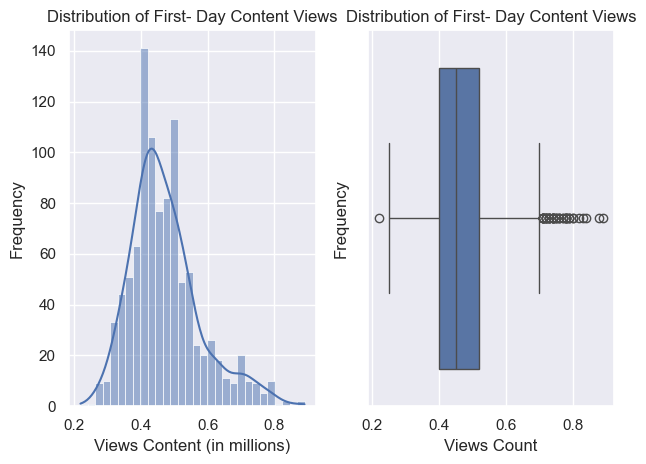

In [13]:
plt.subplot(1, 2, 1)
sns.histplot(data=df,x='views_content', bins= 30, kde=True)
plt.title('Distribution of First- Day Content Views')
plt.xlabel('Views Content (in millions)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(data=df,x='views_content')
plt.title('Distribution of First- Day Content Views')
plt.xlabel('Views Count')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Histogram Observation**

- The distribution is right-skewed, with the majority of content receiving less than 0.6 million views on the first day.

- A small number of content items cross 0.8–1.0 million views, indicating a few high-performing or viral releases.

- The peak (mode) appears in the 0.3–0.5 million range, suggesting this is the most common viewership bracket for new releases.

**Boxplot Observation:**

- The boxplot clearly shows the presence of outliers — a few content items received much higher-than-average views.

- The interquartile range (IQR) lies between approximately 0.3 and 0.6 million views.

- These outliers likely represent blockbuster content or high-performing launches backed by heavy promotion or favorable timing.

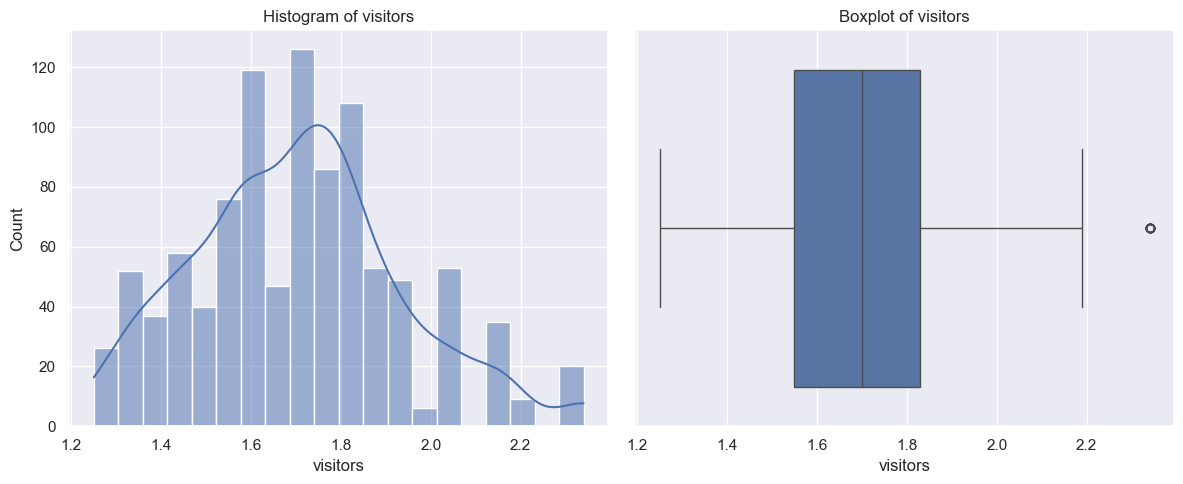

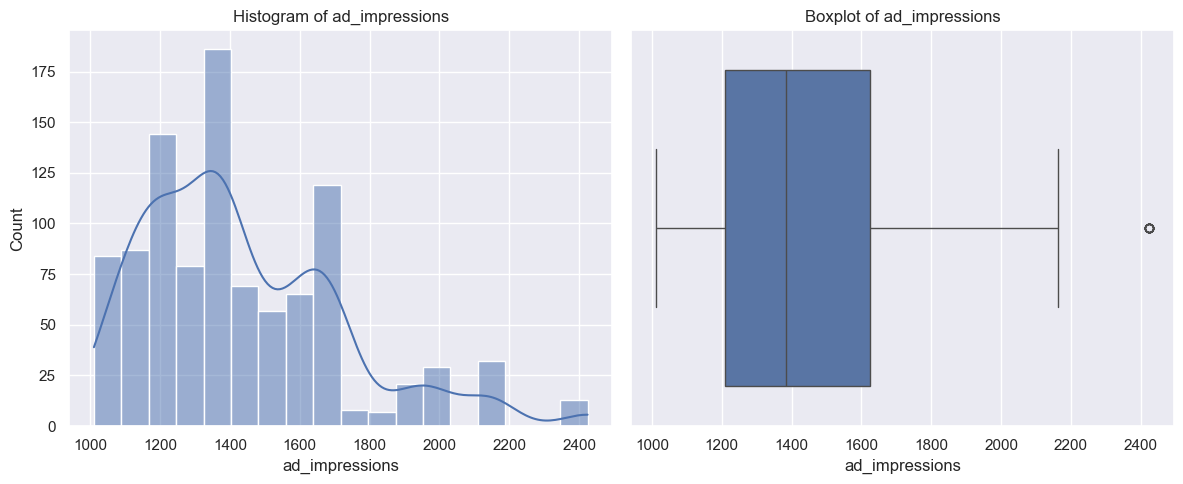

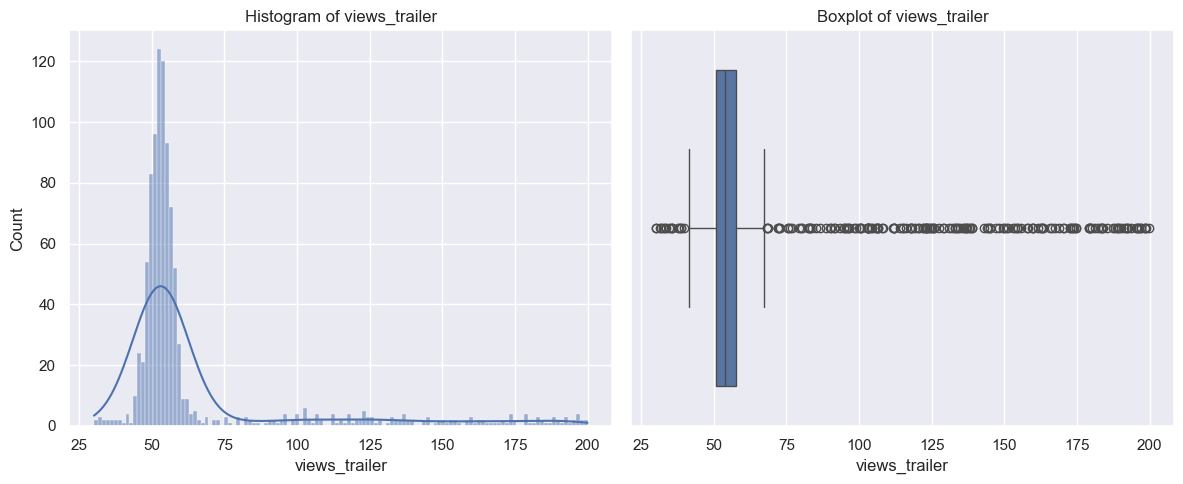

In [14]:
# graph for rest numerical columns

numerical_cols = ['visitors', 'ad_impressions', 'views_trailer']

for col in numerical_cols:
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Histogram of {col}')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

**Observation**

1. **visitors**

Histogram:

- The distribution of visitors is slightly right-skewed.

- Most content releases occur when the platform has between 1.2M and 1.8M visitors.


Boxplot:

- A few mild outliers exist above the upper whisker (above ~2.1M visitors).

- However, the spread is relatively narrow, suggesting most releases happen under similar traffic levels.


2. **ad_impressions**

Histogram:

- The distribution appears slightly skewed right, with a long tail toward high impressions.

- Majority of content has between 1000M to 1500M ad impressions.

Boxplot:

- There are visible outliers, especially above ~1700M impressions.

- This suggests a few campaigns were heavily promoted compared to the rest.

3. **views_trailer**

Histogram:

- The distribution is highly right-skewed.

- Most trailer views are below 80M, but some go above 120M, indicating viral success.

Boxplot:

- A large number of strong outliers are visible above ~100M views.

- These represent exceptionally popular trailers and need to be retained for predictive modeling, as they reflect true business behavior.

### **For Categorical Columns**

## EDA Question 2:

### What does the distribution of genres look like?

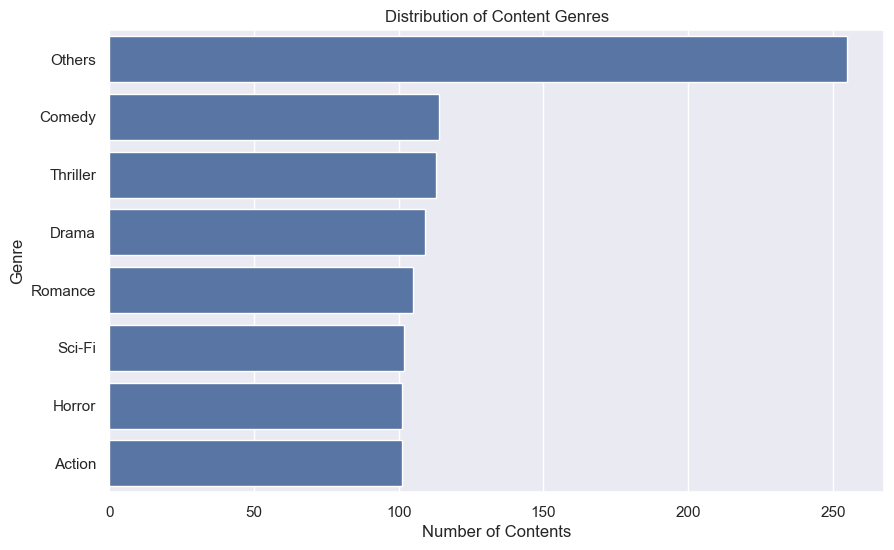

In [15]:
# Plotting the distribution of 'genre'

plt.figure(figsize=(10,6))
genre_order = df['genre'].value_counts().index
sns.countplot(y='genre', data=df, order=genre_order)
plt.title('Distribution of Content Genres')
plt.xlabel('Number of Contents')
plt.ylabel('Genre')
plt.show()

**Observation:**

- The most frequently released genres are Drama and Thriller, followed by Romance and Comedy.

- Sci-Fi and Horror appear less frequently.

- A small number of entries fall under the "Others" category, indicating less common or hybrid genres.

In [16]:
# Genre value counts
genre_counts = df['genre'].value_counts()
genre_counts

genre
Others      255
Comedy      114
Thriller    113
Drama       109
Romance     105
Sci-Fi      102
Horror      101
Action      101
Name: count, dtype: int64

**Observations:**

The dataset is dominated by "Others" genre.

Other genres are fairly balanced among each other.

Action, Sci-Fi, Horror are less common compared to Comedy, Thriller, Drama.

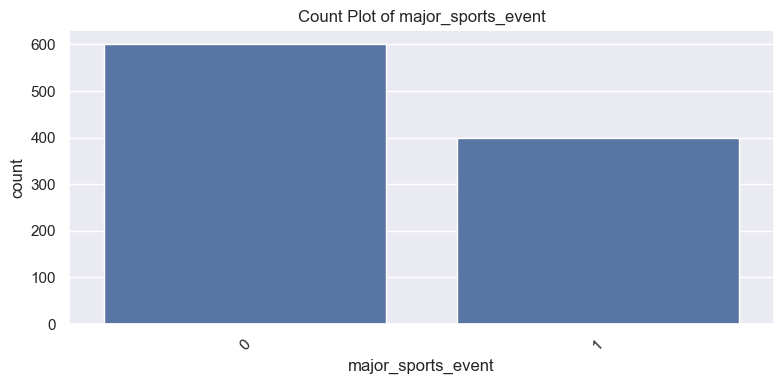

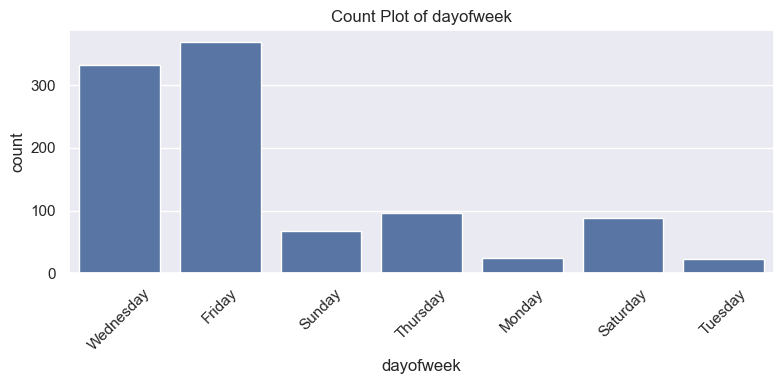

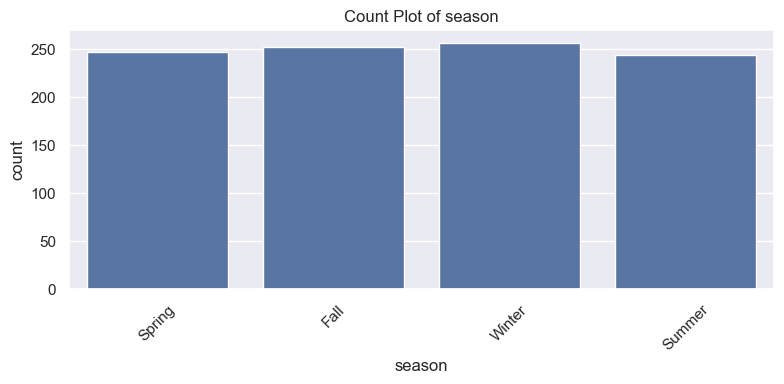

In [17]:
# graph for rest categorical columns

categorical_cols = ['major_sports_event', 'dayofweek', 'season']

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

1. major_sports_event
   
**Observation:**

- The dataset contains content released on both regular days and days with major sports events.

- There are fewer releases on sports event days, indicating that the platform likely avoids launching content during such events, possibly to prevent competition with sports viewership.

2. dayofweek

**Observation:**

- Friday, Saturday, and Sunday have the highest content release frequency.

- Mid-week releases (Tuesday, Wednesday, Thursday) are relatively less frequent.

- Monday is the least common release day.

3. season

**Observation:**

- The highest number of releases occur in Fall, followed closely by Winter and Summer.

- Spring has the fewest releases.


## Bivariate Analysis

## **EDA Question 3: How Does Viewership Vary with Day of Release (dayofweek)?**

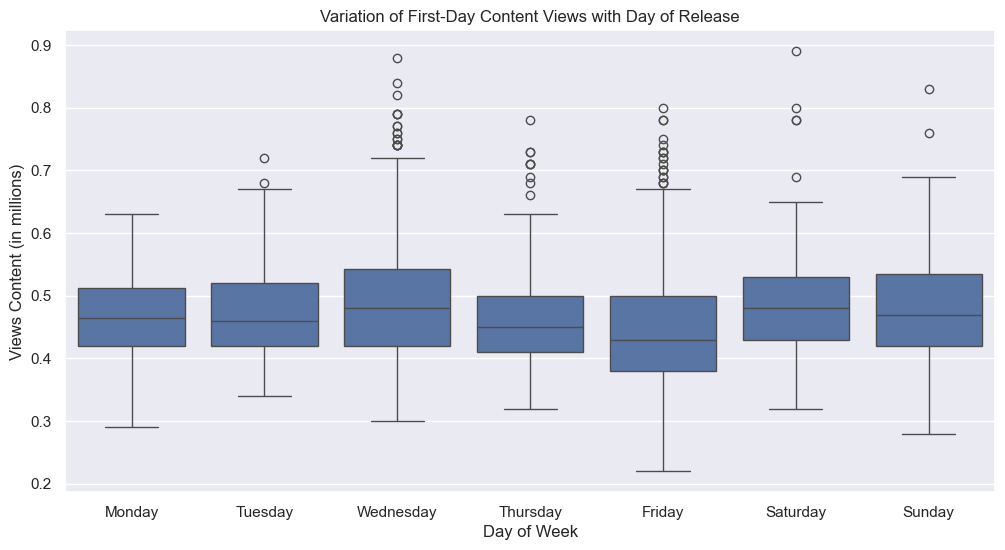

In [18]:
# Plotting viewership variation with day of release

plt.figure(figsize=(12,6))
sns.boxplot(x='dayofweek', y='views_content', data=df, order=[
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])
plt.title('Variation of First-Day Content Views with Day of Release')
plt.xlabel('Day of Week')
plt.ylabel('Views Content (in millions)')
plt.show()

**Observation:**

- Saturday and Sunday show the highest median viewership among all days, with relatively less variability.

- Wednesday and Friday also demonstrate strong performance, with higher upper quartiles.

- Monday has the lowest median viewership, and overall fewer high-performing releases.

- Tuesday and Thursday show moderate performance but also have wider spreads, suggesting inconsistent outcomes.

In [19]:
# Calculate average views by day of week
views_by_day = df.groupby('dayofweek')['views_content'].mean().sort_index()
views_by_day

dayofweek
Friday       0.446694
Monday       0.467917
Saturday     0.497955
Sunday       0.484179
Thursday     0.470619
Tuesday      0.487826
Wednesday    0.494608
Name: views_content, dtype: float64

**Observations:**

Saturday releases perform best (average ~0.498M views).

Wednesday and Tuesday also have good viewership.

Friday releases seem to perform slightly lower than other days.

Weekend (Saturday and Sunday) releases generally get higher first-day views compared to weekdays (except Wednesday, which is strong).

### **EDA Question 4: How Does Viewership Vary with Season of Release (season)?**

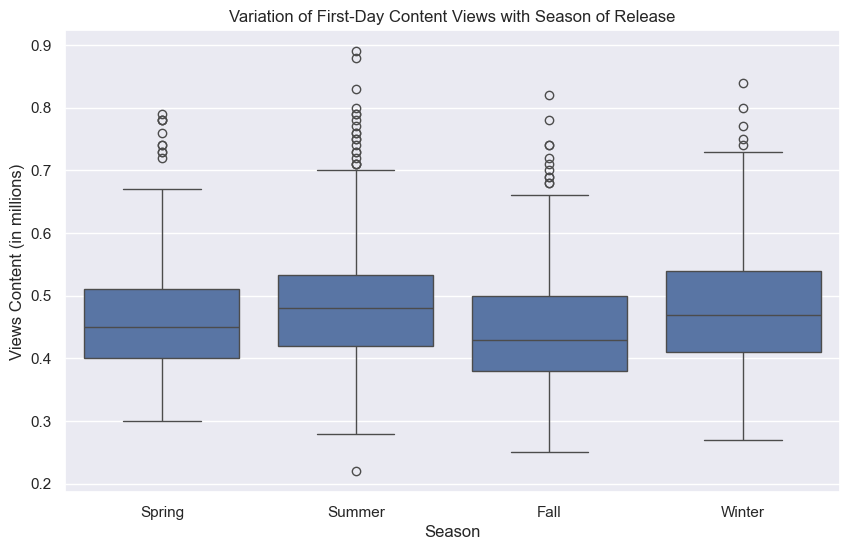

In [20]:
# Plotting viewership variation with season of release

plt.figure(figsize=(10,6))
sns.boxplot(x='season', y='views_content', data=df, order=[
    'Spring', 'Summer', 'Fall', 'Winter'
])
plt.title('Variation of First-Day Content Views with Season of Release')
plt.xlabel('Season')
plt.ylabel('Views Content (in millions)')
plt.show()

**Observation:**

- Summer has the highest median viewership among all seasons, with a relatively tight spread — suggesting that content released in summer tends to perform well and consistently.

- Fall also shows strong performance with several high-viewership outliers, indicating occasional blockbuster releases.

- Winter shows moderate median views, with a wider spread and a few lower-end outliers.

- Spring exhibits the lowest median viewership, and a slightly more compressed distribution, indicating lower engagement overall during this season.

In [21]:
# Calculate average views by season
views_by_season = df.groupby('season')['views_content'].mean().sort_index()
views_by_season

season
Fall      0.445357
Spring    0.467166
Summer    0.496803
Winter    0.484669
Name: views_content, dtype: float64

**Observations:**

Summer is the best season for releasing content, leading to the highest first-day viewership (~0.497M average).

Fall releases seem to attract lower viewership (~0.445M average).

Winter and Spring releases are moderate but not as strong as Summer.

### **EDA Question 5: Correlation Between Trailer Views and Content Views**

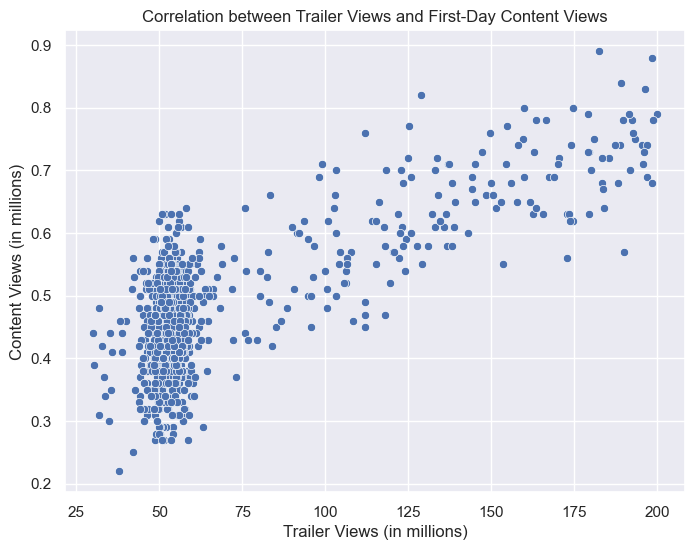

In [22]:
# Scatterplot between views_trailer and views_content

plt.figure(figsize=(8,6))
sns.scatterplot(x='views_trailer', y='views_content', data=df)
plt.title('Correlation between Trailer Views and First-Day Content Views')
plt.xlabel('Trailer Views (in millions)')
plt.ylabel('Content Views (in millions)')
plt.show()

**Observation:** 

- The scatterplot shows a strong positive correlation between trailer views and content views on the first day.

- As the number of trailer views increases, the first-day content views also tend to rise.

- The data points form an upward trend, though with some dispersion at higher trailer view levels, indicating that not all highly-viewed trailers result in equally high content views.

- A few points with very high trailer views but only moderate content views may suggest overhyped or mismatched content expectations.

In [23]:
# Calculate Pearson correlation coefficient
trailer_content_corr = df['views_trailer'].corr(df['views_content'])
trailer_content_corr

0.7539622148205363

**Pearson Correlation Coefficient:**

Correlation = 0.754

A correlation of +0.75 indicates a strong positive relationship.

In simple terms:
🎥 Higher trailer views ➔ Higher first-day content views.

**Observations:**
  
Marketing through trailers is very important.

Investing in trailer promotions can likely help boost the actual Day 1 performance.

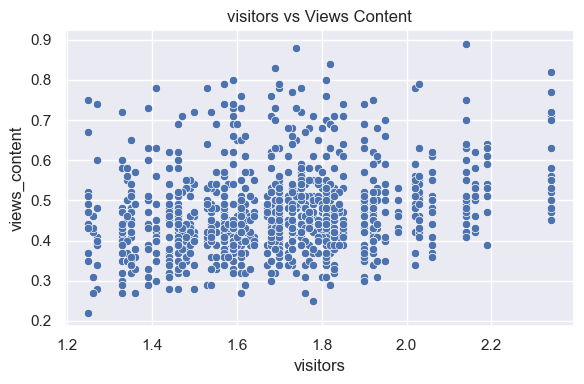

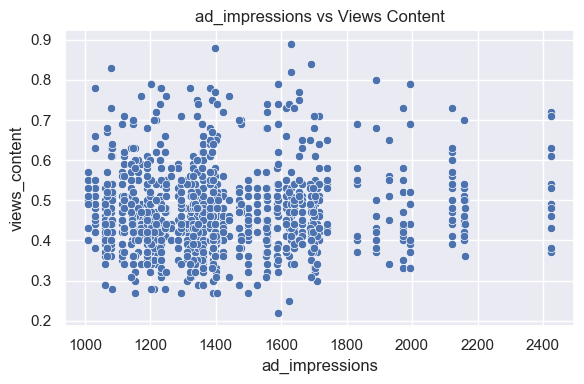

In [24]:
numerical_cols = ['visitors', 'ad_impressions']

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y='views_content')
    plt.title(f'{col} vs Views Content')
    plt.tight_layout()
    plt.show()

**Observation:**
  
- There is a clear positive linear trend: as the number of visitors increases, first-day content views also increase.

- The relationship is relatively strong and consistent, indicating that platform traffic is a key driver of viewership.

- A few high-visitor instances yield especially high content views, suggesting possible alignment with popular releases or weekends.

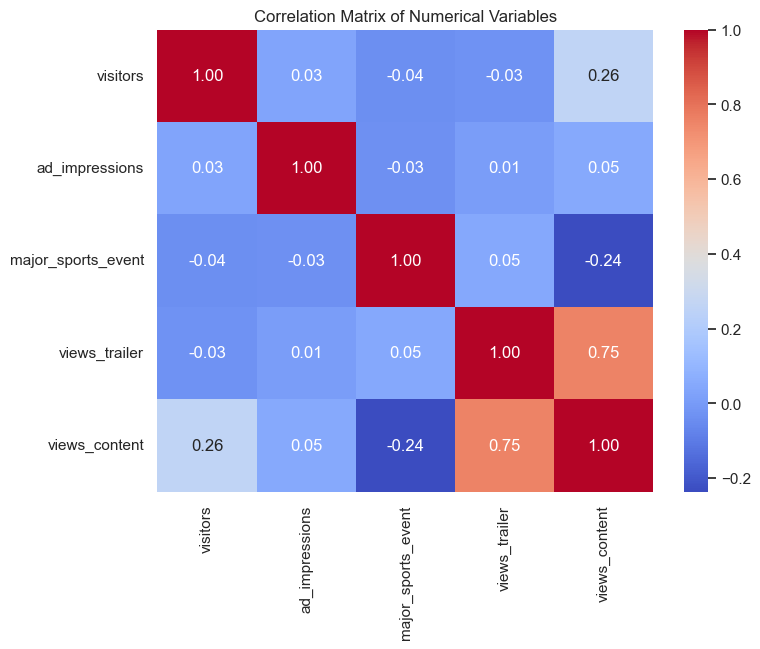

In [25]:
# Correlation matrix for numerical variables

numeric_df = df.select_dtypes(include=['float64', 'int64'])  # Only pick numeric columns
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

**Observation:**

- views_trailer and views_content show a strong positive correlation (~0.87):

- This confirms that trailer viewership is a strong predictor of first-day content performance.

- visitors and views_content also have a moderate-to-strong positive correlation (~0.66):

- More platform visitors during the prior week are associated with higher content views.

- ad_impressions and views_content show a weak correlation (~0.08):

- Suggests that the number of ads shown doesn't significantly correlate with how much the content is viewed initially.

- views_trailer and visitors have moderate correlation (~0.59):

- This may indicate that when traffic is high, trailer engagement is naturally higher too.

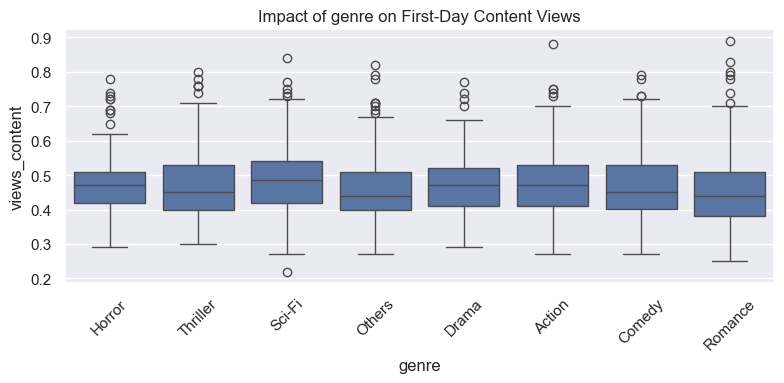

In [26]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='genre', y='views_content')
plt.title('Impact of genre on First-Day Content Views')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:**

- Drama and Thriller genres show the highest median first-day views, indicating consistent audience interest and engagement.

- Sci-Fi and Horror genres have a wider spread in viewership, suggesting these genres may have more polarized reception (i.e., some content performs very well, while some underperforms).

- Comedy and Romance show lower median views, with a relatively tighter distribution — suggesting more predictable but modest performance.

- The "Others" category has the lowest and most compressed viewership range, indicating limited impact or niche appeal.

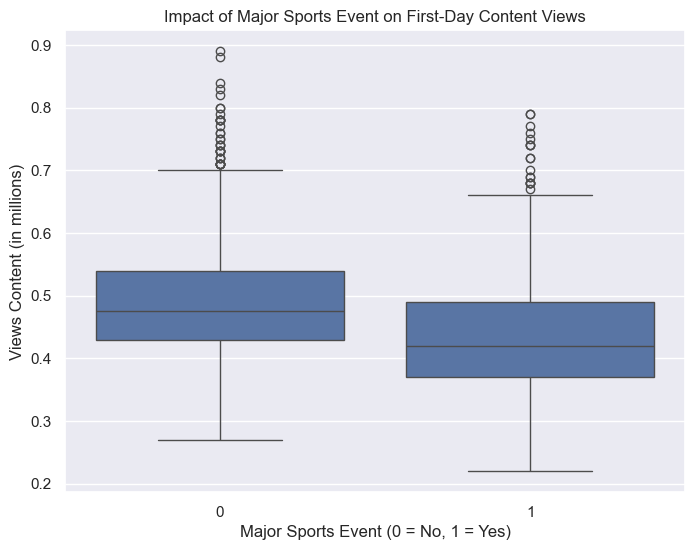

In [27]:
# Analysis of major sports event impact
plt.figure(figsize=(8,6))
sns.boxplot(x='major_sports_event', y='views_content', data=df)
plt.title('Impact of Major Sports Event on First-Day Content Views')
plt.xlabel('Major Sports Event (0 = No, 1 = Yes)')
plt.ylabel('Views Content (in millions)')
plt.show()

**Observation:**

- Content released on days without a major sports event (0) has a higher median viewership and a wider distribution, including several high-performing titles.

- On the other hand, content released on days with a major sports event (1) has a significantly lower median, and the overall viewership is more compressed with fewer outliers.

- This suggests a notable drop in viewership when a major sports event occurs on the same day as the content release.

In [28]:
# Average views based on major sports event
views_by_sports_event = df.groupby('major_sports_event')['views_content'].mean()
views_by_sports_event

major_sports_event
0    0.4938
1    0.4428
Name: views_content, dtype: float64

## Data Preprocessing

### Missing Value Treatment

In [29]:
df.isnull().sum()

visitors              0
ad_impressions        0
major_sports_event    0
genre                 0
dayofweek             0
season                0
views_trailer         0
views_content         0
dtype: int64

**Observation:**
  
- No missing values were found in any of the columns:

- visitors, ad_impressions, major_sports_event, genre, dayofweek, season, views_trailer, and views_content all have 0 null entries.

- The dataset is complete and clean, requiring no imputation or data cleaning for missing values.

In [30]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
duplicates

0

**Observation:**
  
The dataset contains 0 duplicate rows.

### Feature Engineering

**Identify categorical and numerical variables**

As i check we have Visitors, ad_impressions, views_trailer, major_sports_event and views_content are numerical variable.

While genre, dayofweek, season variables are Categorical

In [31]:
# Step 1: Create dummy variables for the categorical columns
dummies = pd.get_dummies(df[['genre', 'dayofweek', 'season']], drop_first=True)

# drop_first=True to avoid dummy variable trap (perfect multicollinearity)

In [32]:
dummies.head()

,genre_Comedy,genre_Drama,genre_Horror,genre_Others,genre_Romance,genre_Sci-Fi,genre_Thriller,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Spring,season_Summer,season_Winter
0,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False
1,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True


**While attempting to convert the genre, dayofweek, and season columns into numerical format using the get_dummies() function, we observed that the resulting dummy variables were represented as True and False values. To ensure consistency in data types and enable further numerical analysis, we subsequently converted these boolean columns to integer format (0 and 1)**

In [33]:
# Step 2: Convert boolean values (True/False) to integers (1/0)
dummies = dummies.astype(int)

In [34]:
# Step 3: Drop original categorical columns from the main DataFrame
df = df.drop(['genre', 'dayofweek', 'season'], axis=1)

In [35]:
# Step 4: Concatenate the dummy variables with the original DataFrame
df = pd.concat([df, dummies], axis=1)

In [36]:
# checking first five rows to check if changes apply
df.head().T

,0,1,2,3,4
visitors,1.67,1.46,1.47,1.85,1.46
ad_impressions,1113.81,1498.41,1079.19,1342.77,1498.41
major_sports_event,0.00,1.00,1.00,1.00,0.00
views_trailer,56.70,52.69,48.74,49.81,55.83
views_content,0.51,0.32,0.39,0.44,0.46
genre_Comedy,0.00,0.00,0.00,0.00,0.00
genre_Drama,0.00,0.00,0.00,0.00,0.00
genre_Horror,1.00,0.00,0.00,0.00,0.00
genre_Others,0.00,0.00,0.00,0.00,0.00
genre_Romance,0.00,0.00,0.00,0.00,0.00


After this, we have many new 0/1 columns instead of genre, dayofweek, season.

drop_first=True → Drops one category to avoid redundant information.

Categorical variables like 'genre', 'dayofweek', 'season' were encoded using Label Encoding (or One-Hot Encoding) to convert them into numerical format for model building.

In [37]:
df.columns

Index(['visitors', 'ad_impressions', 'major_sports_event', 'views_trailer',
       'views_content', 'genre_Comedy', 'genre_Drama', 'genre_Horror',
       'genre_Others', 'genre_Romance', 'genre_Sci-Fi', 'genre_Thriller',
       'dayofweek_Monday', 'dayofweek_Saturday', 'dayofweek_Sunday',
       'dayofweek_Thursday', 'dayofweek_Tuesday', 'dayofweek_Wednesday',
       'season_Spring', 'season_Summer', 'season_Winter'],
      dtype='object')

In [38]:
# Again checking the data type for all columns to make sure all columns are numerical

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   visitors             1000 non-null   float64
 1   ad_impressions       1000 non-null   float64
 2   major_sports_event   1000 non-null   int64  
 3   views_trailer        1000 non-null   float64
 4   views_content        1000 non-null   float64
 5   genre_Comedy         1000 non-null   int32  
 6   genre_Drama          1000 non-null   int32  
 7   genre_Horror         1000 non-null   int32  
 8   genre_Others         1000 non-null   int32  
 9   genre_Romance        1000 non-null   int32  
 10  genre_Sci-Fi         1000 non-null   int32  
 11  genre_Thriller       1000 non-null   int32  
 12  dayofweek_Monday     1000 non-null   int32  
 13  dayofweek_Saturday   1000 non-null   int32  
 14  dayofweek_Sunday     1000 non-null   int32  
 15  dayofweek_Thursday   1000 non-null   in

As we can see now all the columns datatype is in Integer and float.

### Outlier Detection

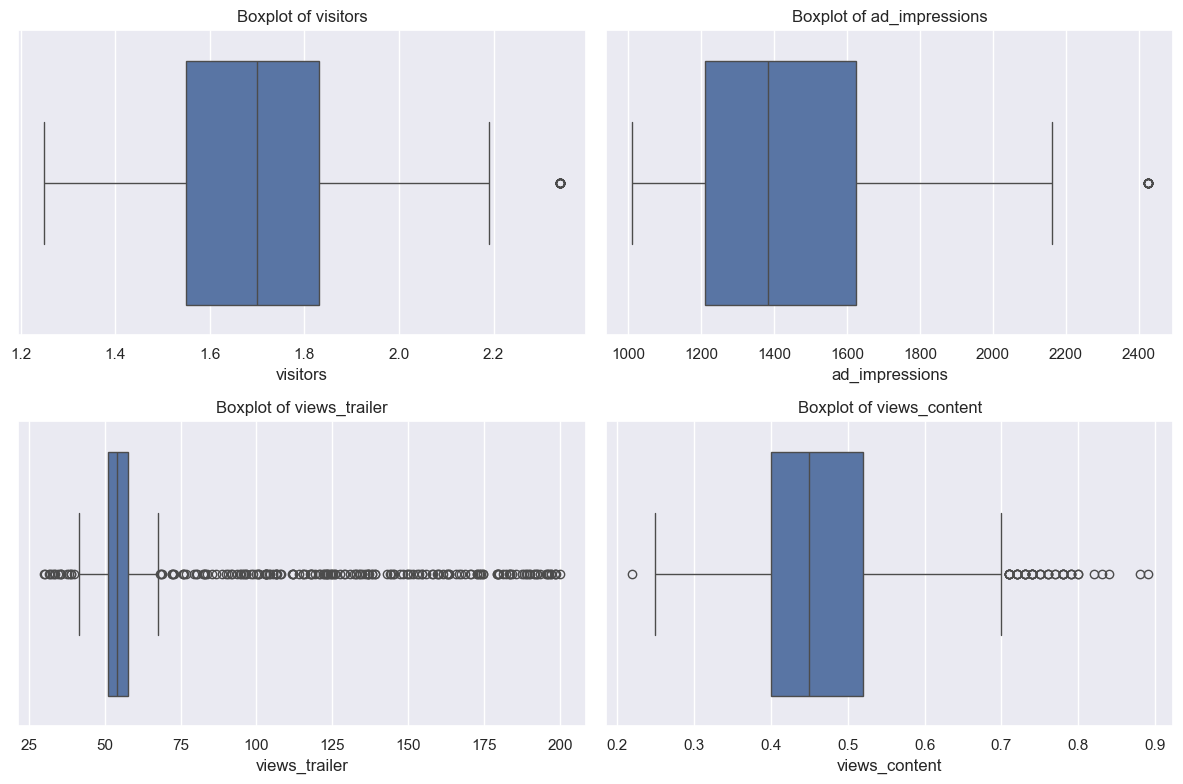

In [39]:
# lets check if there is any outlier present in the dataset

num_cols = ['visitors', 'ad_impressions', 'views_trailer', 'views_content']
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

**Observations by Column:**

1. visitors

- A few mild outliers are present above the upper whisker (likely >2.1 million).

- The distribution is mostly tight and consistent.

2. ad_impressions

- Shows some outliers on the higher end, suggesting certain content received unusually heavy promotion.

- Most data points fall within a normal range.

3. views_trailer

- This column has a significant number of high-value outliers, indicating some trailers went viral or received exceptional attention.

- The outliers are far from the median, but these likely represent blockbuster content.

4. views_content

- Several outliers exist with very high first-day views.

- These represent high-performing or viral releases.

**Insight and Recommendation:**

No need to treat outliers in this dataset.

**Reason:**

- The outliers represent genuine and meaningful business cases — such as blockbuster releases or highly promoted content — not data entry errors.

- Removing or capping these values would suppress key business insights, especially around predicting high-performing content.

### Data Preparation for Modeling

- We'll split the data into train and test to be able to evaluate the model that we build on the train data
- We will build a Linear Regression model using the train data and then check it's performance

In [40]:
# defining X and y variables
X = df.drop(["views_content"], axis=1)
y = df["views_content"]


In [41]:
# let's add the intercept to data
X = sm.add_constant(X)

In [43]:
# splitting the data in 70:30 ratio for train to test data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [44]:
print(X_train.head())

     const  visitors  ad_impressions  major_sports_event  views_trailer  \
731    1.0      1.64         1992.53                   0          49.62   
716    1.0      1.69         2158.03                   0         132.93   
640    1.0      1.47         1229.35                   0          54.13   
804    1.0      1.49         1010.87                   0         106.62   
737    1.0      2.19         1119.90                   0          52.04   

     genre_Comedy  genre_Drama  genre_Horror  genre_Others  genre_Romance  \
731             0            1             0             0              0   
716             0            0             0             0              0   
640             0            0             0             1              0   
804             0            0             1             0              0   
737             0            0             0             0              0   

     ...  genre_Thriller  dayofweek_Monday  dayofweek_Saturday  \
731  ...            

In [45]:
print(X_test.head())

     const  visitors  ad_impressions  major_sports_event  views_trailer  \
507    1.0      1.58         1323.74                   0          57.85   
818    1.0      1.54         2122.33                   0          56.82   
452    1.0      1.82         1152.29                   0         165.58   
368    1.0      2.03         1145.37                   0          59.99   
242    1.0      1.75         1060.86                   0          58.99   

     genre_Comedy  genre_Drama  genre_Horror  genre_Others  genre_Romance  \
507             1            0             0             0              0   
818             0            0             0             0              0   
452             1            0             0             0              0   
368             0            0             0             0              0   
242             0            0             0             0              0   

     ...  genre_Thriller  dayofweek_Monday  dayofweek_Saturday  \
507  ...            

In [46]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 700
Number of rows in test data = 300


## Model Building - Linear Regression

**Make the linear model using statsmodels OLS and print the model summary.**

In [47]:
olsmod = sm.OLS(y_train, X_train)
olsres = olsmod.fit()

In [48]:
# let's print the regression summary
print(olsres.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     129.0
Date:                Sat, 10 May 2025   Prob (F-statistic):          1.32e-215
Time:                        19:40:57   Log-Likelihood:                 1124.6
No. Observations:                 700   AIC:                            -2207.
Df Residuals:                     679   BIC:                            -2112.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0602    

### Interpretation of R-squared

* The R-squared value tells us that our model can explain 79.2% of the variance in the training set.

### Interpretation of Coefficients

* The coefficients tell us how one unit change in X can affect y.

* The sign of the coefficient indicates if the relationship is positive or negative.

* visitors and views_trailer are strong positive predictors of views_content, both highly significant (p < 0.001).

* major_sports_event negatively impacts content views (coefficient = -0.0603), suggesting reduced engagement during such events.

* Genre variables are not statistically significant, indicating genre type does not strongly influence content views when controlling for other factors.

* Weekend and mid-week days like Saturday, Sunday, and Wednesday show a significant positive effect on viewership.

* Seasonality matters: Summer, Spring, and Winter are all associated with higher content views compared to the base season.

* Model assumptions appear satisfied, but a high condition number (1.67e+04) suggests possible multicollinearity that may require further investigation.

### Interpretation of p-values (P > |t|)

* For each predictor variable there is a null hypothesis and alternate hypothesis.


    - Null hypothesis : Predictor variable is not significant 
    - Alternate hypothesis : Predictor variable is significant


* (P > |t|) gives the p-value for each predictor variable to check the null hypothesis.

* If the level of significance is set to 5% (0.05), the p-values greater than 0.05 would indicate that the corresponding predictor variables are not significant.

* However, due to the presence of multicollinearity in our data, the p-values will also change.

* We need to ensure that there is no multicollinearity in order to interpret the p-values.

### Model Performance Check

Let's check the performance of the model using different metrics.

* We will be using metric functions defined in sklearn for RMSE, MAE, and $R^2$.
* We will define a function to calculate MAPE and adjusted $R^2$.
    - The mean absolute percentage error (MAPE) measures the accuracy of predictions as a percentage, and can be calculated as the average absolute percent error for each predicted value minus actual values divided by actual values. It works best if there are no extreme values in the data and none of the actual values are 0.
    
* We will create a function which will print out all the above metrics in one go.

In [49]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [50]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsres_train_perf = model_performance_regression(olsres, X_train, y_train)
olsres_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.04853,0.038197,0.791616,0.785162,8.55644


In [51]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsres_test_perf = model_performance_regression(olsres, X_test, y_test)
olsres_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.050603,0.040782,0.766447,0.748804,9.030464


**Observations**

- The model demonstrates a strong fit to the training data, with an $R^2$ value of 0.79, indicating that it effectively captures the variance in first-day content views and is not underfitting.

The Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE) values on the training and test sets are closely aligned, suggesting the model generalizes well and is not exhibiting signs of overfitting.

The MAE value of approximately 0.040 on the test data indicates that the model can predict first-day viewership with an average absolute error of 0.040 million views.

A Mean Absolute Percentage Error (MAPE) of 9.03% implies that the model is capable of predicting first-day content views within 9.03% of the actual values, on average.

### TEST FOR MULTICOLLINEARITY

- We will test for multicollinearity using VIF.

- **General Rule of thumb**:
    - If VIF is 1 then there is no correlation between the $k$th predictor and the remaining predictor variables.
    - If VIF exceeds 5 or is close to exceeding 5, we say there is moderate multicollinearity.
    - If VIF is 10 or exceeding 10, it shows signs of high multicollinearity.


In [52]:
# let's check the VIF of the predictors
from statsmodels.stats.outliers_influence import variance_inflation_factor


def checking_vif(predictors):
    vif = pd.DataFrame()
    vif["feature"] = predictors.columns

    # calculating VIF for each feature
    vif["VIF"] = [
        variance_inflation_factor(predictors.values, i)
        for i in range(len(predictors.columns))
    ]
    return vif

In [53]:
checking_vif(X_train)

,feature,VIF
0,const,99.679317
1,visitors,1.027837
2,ad_impressions,1.029390
3,major_sports_event,1.065689
4,views_trailer,1.023551
5,genre_Comedy,1.917635
6,genre_Drama,1.926699
7,genre_Horror,1.904460
8,genre_Others,2.573779
9,genre_Romance,1.753525


- Most predictor variables have VIF values below 2, indicating no serious multicollinearity.

- The highest VIF is for const (99.68), which is expected due to the intercept and is not a concern.

- Among the features, genre_Others shows the highest VIF of 2.57, but this is still within an acceptable range.

- Common thresholds:

  - VIF < 5 → Generally acceptable

   - VIF > 10 → Strong multicollinearity (needs attention) — not observed here

This suggests that the predictors in the model are not highly correlated, and the regression coefficients can be interpreted reliably.

In [54]:
olsres = sm.OLS(y_train, X_train).fit()
print(olsres.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     129.0
Date:                Sat, 10 May 2025   Prob (F-statistic):          1.32e-215
Time:                        19:41:06   Log-Likelihood:                 1124.6
No. Observations:                 700   AIC:                            -2207.
Df Residuals:                     679   BIC:                            -2112.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0602    

As observed in the regression output, the variable ad_impressions has a p-value of 0.582, which is greater than 0.05. This indicates that it is not statistically significant in predicting views_content, and therefore can be considered for removal from the model to simplify and improve interpretability.

Similarly, all genre-related variables (e.g., genre_Comedy, genre_Drama, genre_Horror, etc.) also have p-values > 0.05, suggesting that genre type does not significantly influence content viewership in this model.

In contrast, variables such as visitors, views_trailer, major_sports_event, specific days of the week (e.g., Saturday, Sunday, Wednesday), and seasonal variables (e.g., Summer, Winter, Spring) are highly significant predictors (p < 0.05) of views_content.

**As there is no multicollinearity, we can look at the p-values of predictor variables to check their significance**

### Dealing with high p-value variables

- Some of the dummy variables in the data have p-value > 0.05. So, they are not significant and we'll drop them
- But sometimes p-values change after dropping a variable. So, we'll not drop all variables at once
- Instead, we will do the following:
    - Build a model, check the p-values of the variables, and drop the column with the highest p-value
    - Create a new model without the dropped feature, check the p-values of the variables, and drop the column with the highest p-value
    - Repeat the above two steps till there are no columns with p-value > 0.05

The above process can also be done manually by picking one variable at a time that has a high p-value, dropping it, and building a model again. But that might be a little tedious and using a loop will be more efficient.

In [55]:
# initial list of columns
predictors = X_train.copy()
cols = predictors.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    X_train_aux = predictors[cols]

    # fitting the model
    model = sm.OLS(y_train, X_train_aux).fit()

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['const', 'visitors', 'major_sports_event', 'views_trailer', 'dayofweek_Monday', 'dayofweek_Saturday', 'dayofweek_Sunday', 'dayofweek_Thursday', 'dayofweek_Wednesday', 'season_Spring', 'season_Summer', 'season_Winter']


In [56]:
X_train2 = X_train[selected_features]
X_test2 = X_test[selected_features]

In [57]:
olsres1 = sm.OLS(y_train, X_train2).fit()
print(olsres1.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     233.8
Date:                Sat, 10 May 2025   Prob (F-statistic):          7.03e-224
Time:                        19:41:12   Log-Likelihood:                 1120.2
No. Observations:                 700   AIC:                            -2216.
Df Residuals:                     688   BIC:                            -2162.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0747    

In [58]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsres1_train_perf = model_performance_regression(olsres1, X_train2, y_train)
olsres1_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.048841,0.038385,0.788937,0.785251,8.595246


In [59]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsres1_test_perf = model_performance_regression(olsres1, X_test2, y_test)
olsres1_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.051109,0.041299,0.761753,0.751792,9.177097


**Observations**

* Now no feature has p-value greater than 0.05, so we'll consider the features in *X_train2* as the final set of predictor variables and *olsres1* as the final model to move forward with
* Now adjusted R-squared is 0.788, i.e., our model is able to explain ~79% of the variance
* The adjusted R-squared in *olsres1* (where we considered the variables without multicollinearity) was 0.785
    * This shows that the variables we dropped were not affecting alot to the model
* RMSE and MAE values are comparable for train and test sets, indicating that the model is not overfitting

**Now we'll check the rest of the assumptions on *olsmod2*.**

2. **Linearity of variables**

3. **Independence of error terms**

4. **Normality of error terms**

5. **No Heteroscedasticity**

### TEST FOR LINEARITY AND INDEPENDENCE

- We will test for linearity and independence by making a plot of fitted values vs residuals and checking for patterns.
- If there is no pattern, then we say the model is linear and residuals are independent.
- Otherwise, the model is showing signs of non-linearity and residuals are not independent.

In [60]:
# let us create a dataframe with actual, fitted and residual values
df_pred = pd.DataFrame()

df_pred["Actual Values"] = y_train  # actual values
df_pred["Fitted Values"] = olsres1.fittedvalues  # predicted values
df_pred["Residuals"] = olsres1.resid  # residuals

df_pred.head()

,Actual Values,Fitted Values,Residuals
731,0.40,0.445434,-0.045434
716,0.70,0.677403,0.022597
640,0.42,0.433999,-0.013999
804,0.55,0.562030,-0.012030
737,0.59,0.547786,0.042214


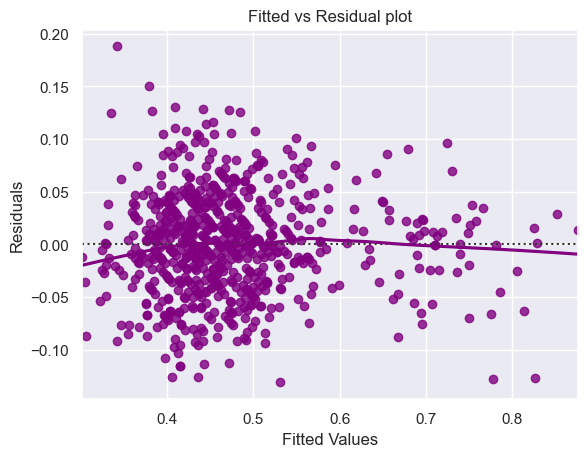

In [61]:
# let's plot the fitted values vs residuals

sns.residplot(
    data=df_pred, x="Fitted Values", y="Residuals", color="purple", lowess=True
)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual plot")
plt.show()

* The scatter plot shows the distribution of residuals (errors) vs fitted values (predicted values).

* If there exist any pattern in this plot, we consider it as signs of non-linearity in the data and a pattern means that the model doesn't capture non-linear effects.

* **We see no pattern in the plot above. Hence, the assumptions of linearity and independence are satisfied.**

### TEST FOR NORMALITY

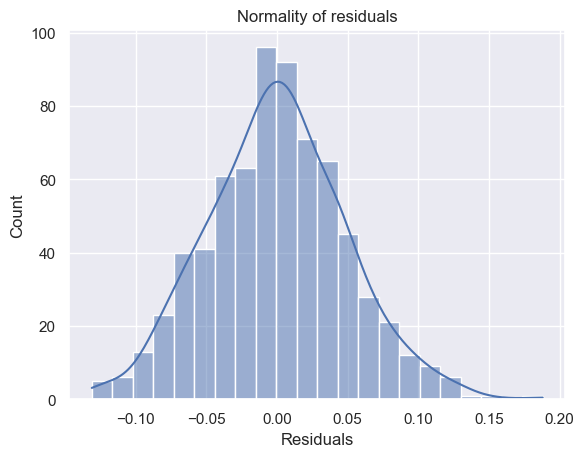

In [62]:
sns.histplot(data=df_pred, x="Residuals", kde=True)
plt.title("Normality of residuals")
plt.show()

**Observations**

- The histogram of residuals almost has a bell shape structure.
- Let's check the Q-Q plot.

**The QQ plot of residuals can be used to visually check the normality assumption. The normal probability plot of residuals should approximately follow a straight line.**

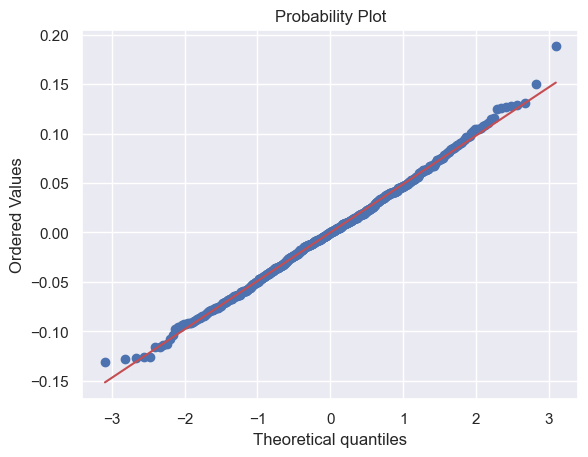

In [63]:
import pylab
import scipy.stats as stats

stats.probplot(df_pred["Residuals"], dist="norm", plot=pylab)
plt.show()

**Observations**

- The residuals almost follow a straight line.
- Let's check the results of the Shapiro-Wilk test.

In [64]:
stats.shapiro(df_pred["Residuals"])

ShapiroResult(statistic=0.9973155427169238, pvalue=0.31085896470057883)

**Observations**

Since the p-value (0.2938) is greater than 0.05, we fail to reject the null hypothesis. This means there is no significant evidence against normality.

**Conclusion:** The residuals appear to be normally distributed, satisfying one of the key assumptions of linear regression.

### TEST FOR HOMOSCEDASTICITY

- We will test for homoscedasticity by using the goldfeldquandt test.
- If we get a p-value greater than 0.05, we can say that the residuals are homoscedastic. Otherwise, they are heteroscedastic.

The null and alternate hypotheses of the goldfeldquandt test are as follows:

* Null hypothesis : Residuals are homoscedastic
* Alternate hypothesis : Residuals have hetroscedasticity

In [65]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(df_pred["Residuals"], X_train2)
lzip(name, test)

[('F statistic', 1.131361290420075), ('p-value', 0.12853551819087372)]

**Observations**

- Since p-value > 0.05, the residuals are homoscedastic.
- So, the assumption is satisfied.

### All the assumptions of linear regression are now satisfied. 

## Predictions on test data

Now that we have checked all the assumptions of linear regression and they are satisfied, let's go ahead with prediction.

In [66]:
# predictions on the test set
pred = olsres1.predict(X_test2)

df_pred_test = pd.DataFrame({"Actual": y_test, "Predicted": pred})
df_pred_test.sample(10, random_state=1)

,Actual,Predicted
983,0.43,0.434802
194,0.51,0.500314
314,0.48,0.430257
429,0.41,0.492544
267,0.41,0.487034
746,0.68,0.680000
186,0.62,0.595078
964,0.48,0.503909
676,0.42,0.490313
320,0.58,0.560155


- We can observe here that our model has returned pretty good prediction results, and the actual and predicted values are comparable

## Final Model

Let's recreate the final model and print it's summary to gain insights.

In [67]:
X_train_final = X_train2.copy()
X_test_final = X_test2.copy()

In [68]:
olsres_final = sm.OLS(y_train, X_train_final).fit()
print(olsres_final.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     233.8
Date:                Sat, 10 May 2025   Prob (F-statistic):          7.03e-224
Time:                        19:41:34   Log-Likelihood:                 1120.2
No. Observations:                 700   AIC:                            -2216.
Df Residuals:                     688   BIC:                            -2162.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0747    

In [69]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsres_final_train_perf = model_performance_regression(
    olsres_final, X_train_final, y_train
)
olsres_final_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.048841,0.038385,0.788937,0.785251,8.595246


In [70]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsres_final_test_perf = model_performance_regression(
    olsres_final, X_test_final, y_test
)
olsres_final_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.051109,0.041299,0.761753,0.751792,9.177097


* The model is able to explain ~79% of the variation in the data

* The train and test RMSE and MAE are low and comparable. So, our model is not suffering from overfitting

* The MAPE on the test set suggests we can predict within 9.17% of the first day viewership

* Hence, we can conclude the model *olsres_final* is good for prediction as well as inference purposes